In [1]:
# PSG（Polysomnography，多导睡眠监测/多导睡眠图）是一种在睡眠医学中使用的综合性生理监测技术，
# 通过同步记录睡眠过程中的多种生理信号，来评估睡眠结构、质量和相关病理事件

In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

from mne.datasets.sleep_physionet.age import fetch_data

In [4]:
# 加载数据

# 定义受试者编号常量：ALICE = 0（第一位受试者），BOB = 1（第二位受试者）
ALICE, BOB = 0, 1

# 从 Sleep Physionet 数据集下载并获取指定受试者的 PSG 数据文件路径。
# subjects=[ALICE, BOB] : 下载第 0 号和第 1 号受试者的数据
# recording=[1]         : 取每个受试者的第 1 条记录（该数据集通常每人有 1~2 条整夜记录）
# path='../data'        : 数据存放的本地目录，若不存在则自动下载
# 返回值是一个列表的列表，每个内层列表包含该受试者的 [PSG文件, 注释文件]
[alice_files, bob_files] = fetch_data(subjects=[ALICE, BOB], recording=[1], path='../data')

# 通道名称映射字典：将 EDF 文件中的原始通道名映射为 MNE 认可的标准通道类型
# 这样做是为了让 MNE 正确识别各类生理信号，以便后续按类型筛选和处理
mapping = {'EOG horizontal': 'eog',      # 水平眼电 → EOG 类型
           'Resp oro-nasal': 'misc',     # 口鼻呼吸信号 → 杂项（非脑电/眼电/肌电）
           'EMG submental': 'misc',      # 下颌肌电 → 杂项（也可设为 'emg'）
           'Temp rectal': 'misc',        # 直肠温度 → 杂项
           'Event marker': 'misc',}      # 事件标记 → 杂项

# 读取 ALICE 的 PSG 原始数据（EDF 格式）
# 返回的 raw_train 是一个 Raw 对象，包含所有通道的时序信号和元信息
raw_train = mne.io.read_raw_edf(alice_files[0])

# 读取 ALICE 对应的睡眠分期注释文件
# 该文件包含睡眠技师人工判读的分期结果（如 Sleep stage W, N1, N2, N3, R），
# 以时间戳和持续时长的形式记录，后续可通过 set_annotations() 关联到 Raw 对象
annot_train = mne.read_annotations(alice_files[1])

  0%|                                              | 0.00/48.3M [00:00<?, ?B/s]

  0%|                                              | 0.00/4.62k [00:00<?, ?B/s]

  0%|                                              | 0.00/51.1M [00:00<?, ?B/s]

  0%|                                              | 0.00/3.90k [00:00<?, ?B/s]

Download complete in 07m54s (94.8 MB)
Extracting EDF parameters from ..\data\physionet-sleep-data\SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...


C:\Users\74453\AppData\Local\Temp\ipykernel_4112\2640678304.py:12: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_train = mne.io.read_raw_edf(alice_files[0])
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\2640678304.py:12: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw_train = mne.io.read_raw_edf(alice_files[0])
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\2640678304.py:12: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw_train = mne.io.read_raw_edf(alice_files[0])


C:\Users\74453\AppData\Local\Temp\ipykernel_4112\3912106961.py:2: RuntimeWarning: The unit for channel(s) EMG submental, Event marker, Resp oro-nasal, Temp rectal has changed from V to NA.
  raw_train.set_channel_types(mapping)
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\3912106961.py:4: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  raw_train.plot(duration=40, scalings='auto')


Using matplotlib as 2D backend.


C:\Users\74453\AppData\Local\Temp\ipykernel_4112\3912106961.py:4: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  raw_train.plot(duration=40, scalings='auto')
D:\Miniconda\envs\mne_demo_env\lib\site-packages\mne\viz\_mpl_figure.py:2160: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  self.canvas.draw_idle()
D:\Miniconda\envs\mne_demo_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


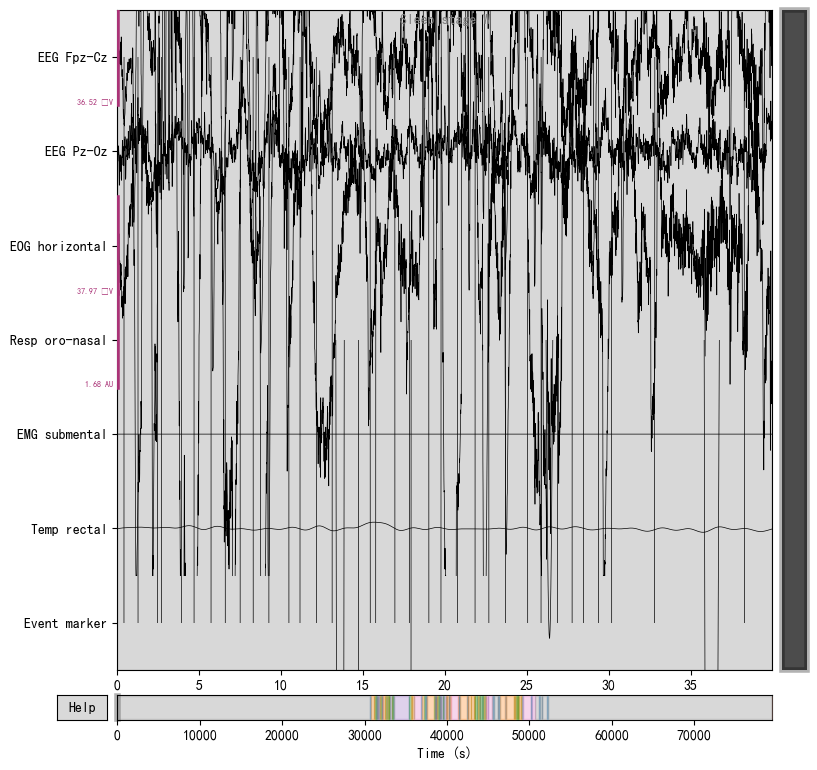

In [5]:
# 将读取到的睡眠分期注释（annotations）关联到 Raw 对象上。
# 这样每个睡眠阶段（如 W、N1、N2、N3、R）的时间范围和标签就被绑定到原始信号中，
# 后续可用于按睡眠阶段切分 epoch 或在波形图上标注分期信息。
# emit_warning=False : 抑制可能因注释时间与数据长度不匹配而产生的警告。
raw_train.set_annotations(annot_train, emit_warning=False)

# 根据 mapping 字典批量设置各通道的类型。
# 这一步至关重要，它告诉 MNE 每个通道是脑电（eeg）、眼电（eog）还是杂项（misc），
# 使得后续 pick_types() 筛选、ICA 去伪迹、以及绘图颜色区分都能正确执行。
raw_train.set_channel_types(mapping)

# 绘制原始 PSG 信号的连续波形浏览图。
# duration=40     : 每个窗口显示 40 秒的数据，便于概览整夜记录中的片段。
# scalings='auto' : 自动计算各通道类型的幅度缩放比例，使 EEG、EOG、EMG 等不同量级的信号
#                   在纵轴上显示得大小适中，避免某类信号因幅值过大或过小而看不清。
raw_train.plot(duration=40, scalings='auto')
plt.show()

Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]


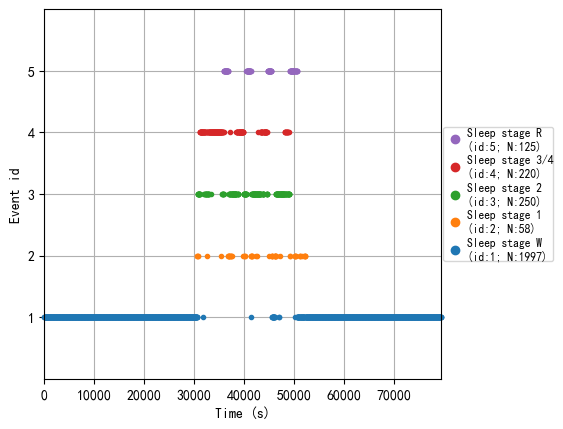

In [7]:
# 定义睡眠分期描述到整数事件编码的映射字典。
# 将人工判读的睡眠阶段标签（如 'Sleep stage W'）转换为数值型事件 ID，
# 便于 MNE 后续进行 epoch 分段和机器学习处理。
# N3 和 N4 期都映射为 4，表示将两者合并（按 AASM 标准 N3/N4 已合并为 N3）。
annotation_desc_2_event_id = {'Sleep stage W': 1,
                              'Sleep stage 1': 2,
                              'Sleep stage 2': 3,
                              'Sleep stage 3': 4,
                              'Sleep stage 4': 4,
                              'Sleep stage R': 5,}

# 将 Raw 对象中的 annotations 转换为 MNE 标准的事件数组（events）。
# events_train 形状为 (n_events, 3)，每行含义：[采样点索引, 0, 事件编码]。
# chunk_duration=30. : 每个睡眠分期注释按 30 秒为一段进行切分（标准睡眠分期 epoch 长度），
#                      生成分段后的事件标记，对应 30 秒一个的睡眠 epoch。
events_train, _ = mne.events_from_annotations(raw_train,
                                              event_id=annotation_desc_2_event_id, chunk_duration=30.)

# 重新定义用于绘图和展示的事件标签字典。
# 这里将编码 4 显示为 'Sleep stage 3/4'，更清晰地表示 N3 与 N4 已合并。
event_id = {'Sleep stage W': 1,
            'Sleep stage 1': 2,
            'Sleep stage 2': 3,
            'Sleep stage 3/4': 4,
            'Sleep stage R': 5,}

# 绘制睡眠分期事件的时间分布图。
# 横轴为时间，纵轴为不同睡眠阶段，彩色条带展示整夜各阶段的切换过程。
# sfreq=raw_train.info['sfreq'] : 使用原始数据的采样频率，将采样点索引转换为物理时间。
mne.viz.plot_events(events_train, event_id=event_id, sfreq=raw_train.info['sfreq'])

# 获取 matplotlib 当前默认的颜色循环列表，用于后续为各睡眠阶段指定一致的颜色。
# 例如 W 期、N1 期、N2 期等在波形图或地形图中使用与事件图相同的配色。
stage_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [10]:
# 计算每个 epoch 的时间窗口终点。
# 标准睡眠分期以 30 秒为一个 epoch，这里用 30 减去一个采样周期（1/sfreq），
# 是为了确保每个 epoch 严格落在 30 秒范围内，避免在边界处多取一个采样点。
tmax = 30. - 1. / raw_train.info['sfreq']

# 根据事件标记将原始 PSG 连续数据切分为多个 epoch
epochs_train = mne.Epochs(raw_train, events_train, event_id, tmax, tmin=0., baseline=None)

# 打印 Epochs 对象的基本信息，包括总 epoch 数、各睡眠阶段的 trial 数量、时间窗口、通道数、采样频率等
print(epochs_train)

Not setting metadata
2650 matching events found
No baseline correction applied
0 projection items activated
<Epochs | 2650 events (good & bad), 0 – 29.99 s (baseline off), ~12 KiB, data not loaded,
 'Sleep stage W': 1997
 'Sleep stage 1': 58
 'Sleep stage 2': 250
 'Sleep stage 3/4': 220
 'Sleep stage R': 125>


In [11]:
# 加载 BOB 的数据

In [12]:
raw_test = mne.io.read_raw_edf(bob_files[0])
annot_test = mne.read_annotations(bob_files[1])
raw_test.set_annotations(annot_test, emit_warning=False)
raw_test.set_channel_types(mapping)
events_test, _ = mne.events_from_annotations(raw_test,
                                             event_id=annotation_desc_2_event_id, chunk_duration=30.)
epochs_test = mne.Epochs(raw_test, events_test, event_id, tmin=0., tmax=tmax, baseline=None)
print(epochs_test)

Extracting EDF parameters from ..\data\physionet-sleep-data\SC4011E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...


C:\Users\74453\AppData\Local\Temp\ipykernel_4112\1876664644.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_test = mne.io.read_raw_edf(bob_files[0])
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\1876664644.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw_test = mne.io.read_raw_edf(bob_files[0])
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\1876664644.py:1: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw_test = mne.io.read_raw_edf(bob_files[0])
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\1876664644.py:4: RuntimeWarning: The unit for channel(s) EMG submental, Event marker, Resp oro-nasal, Temp rectal has changed from V to NA.
  raw_test.set_channel_types(mapping)


Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]
Not setting metadata
2802 matching events found
No baseline correction applied
0 projection items activated
<Epochs | 2802 events (good & bad), 0 – 29.99 s (baseline off), ~12 KiB, data not loaded,
 'Sleep stage W': 1856
 'Sleep stage 1': 109
 'Sleep stage 2': 562
 'Sleep stage 3/4': 105
 'Sleep stage R': 170>


In [13]:
# 特征工程

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Loading data for 58 events and 3000 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).


C:\Users\74453\AppData\Local\Temp\ipykernel_4112\673338674.py:5: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].plot_psd(area_mode=None, color=color, ax=ax,
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\673338674.py:5: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].plot_psd(area_mode=None, color=color, ax=ax,
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\673338674.py:5: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].plot_psd(area_mode=None, color=

Averaging across epochs before plotting...
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Loading data for 250 events and 3000 original time points ...


C:\Users\74453\AppData\Local\Temp\ipykernel_4112\673338674.py:5: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].plot_psd(area_mode=None, color=color, ax=ax,
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\673338674.py:5: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].plot_psd(area_mode=None, color=color, ax=ax,
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\673338674.py:5: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].plot_psd(area_mode=None, color=

0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows


...

C:\Users\74453\AppData\Local\Temp\ipykernel_4112\673338674.py:5: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].plot_psd(area_mode=None, color=color, ax=ax,
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\673338674.py:5: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].plot_psd(area_mode=None, color=color, ax=ax,
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\673338674.py:5: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].plot_psd(area_mode=None, color=

0 bad epochs dropped


C:\Users\74453\AppData\Local\Temp\ipykernel_4112\673338674.py:5: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].plot_psd(area_mode=None, color=color, ax=ax,
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\673338674.py:5: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].plot_psd(area_mode=None, color=color, ax=ax,
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\673338674.py:5: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].plot_psd(area_mode=None, color=

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


C:\Users\74453\AppData\Local\Temp\ipykernel_4112\673338674.py:9: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
D:\Miniconda\envs\mne_demo_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


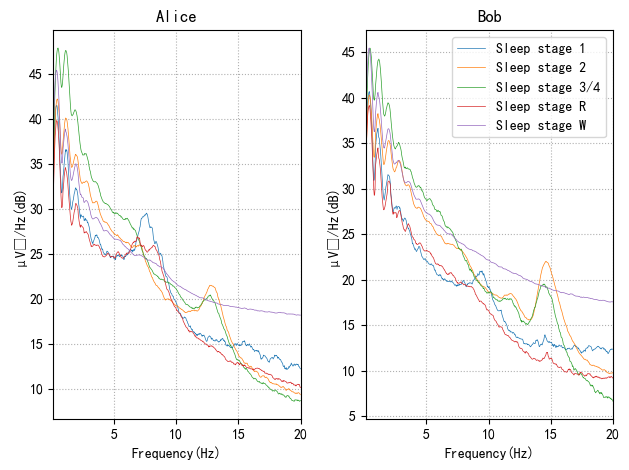

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2)
stages = sorted(event_id.keys())
for ax, title, epochs in zip([ax1, ax2], ['Alice', 'Bob'], [epochs_train, epochs_test]):
    for stage, color in zip(stages, stage_colors):
        epochs[stage].compute_psd().plot()(area_mode=None, color=color, ax=ax, fmin=0.1, fmax=20.,
                                           show=False, average=True, spatial_colors=False)
    ax.set(title=title, xlabel='Frequency(Hz)', ylabel='μV²/Hz(dB)')
ax2.legend(ax2.lines[2::3], stages)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer

# 使用机器学习中的随机森林判断睡眠类型

In [22]:
# 计算 EEG 各频段功率特征的转换器函数
# 输入为 MNE Epochs 对象，输出为每个 epoch 的频段功率特征向量，常用于睡眠分期、情绪识别等基于频谱特征的分类任务
def eeg_power_band(epochs):
    # 定义经典的 EEG 频段及其频率范围（单位：Hz）。
    # 这些频段是睡眠分期和认知状态分析中最常用的生理指标：
    # delta（深睡眠标志）、theta（浅睡眠/困倦）、alpha（清醒放松）、sigma（睡眠纺锤波）、beta（清醒活跃/认知负荷）
    FREQ_BANDS = {'delta': [0.5, 4.5],
                  'theta': [4.5, 8.5],
                  'alpha': [8.5, 11.5],
                  'sigma': [11.5, 15.5],
                  'beta': [15.5, 30],}

    # 使用 Welch 方法计算每个 epoch 中 EEG 通道的功率谱密度（PSD）。
    # method='welch' : 采用 Welch 周期图法，通过分段加窗平均降低 PSD 估计方差。
    # picks='eeg'    : 只选取 EEG 通道进行计算，排除 EOG、EMG 等辅助通道。
    # fmin=0.5, fmax=30. : 计算 0.5–30 Hz 范围内的 PSD，覆盖上述五个频段。
    # psds 的形状为 (n_epochs, n_channels, n_freqs)，freqs 为对应的频率轴数组。
    spectrum = epochs.compute_psd(method='welch', picks='eeg', fmin=0.5, fmax=30.)
    psds = spectrum.get_data()
    freqs = spectrum.freqs

    # 将 PSD 归一化为相对功率（relative power）。
    # 沿频率轴（axis=1）求和，然后每个频点的功率除以总功率，
    # 得到各频段占总功率的比例，消除个体间和通道间的绝对幅值差异。
    # keepdims=True 保持维度对齐，便于广播除法。
    psds /= np.sum(psds, axis=1, keepdims=True)

    # 初始化特征列表，用于存储每个频段的功率特征。
    X = []

    # 遍历每个频段的频率范围，提取对应的平均功率。
    for fmin, fmax in FREQ_BANDS.values():
        # 通过布尔掩码筛选当前频段内的频率索引。
        # psds[:, :, (freqs >= fmin) & (freqs < fmax)] 提取该频段内所有频点的 PSD 值，
        # .mean(axis=-1) 沿频率轴求平均，得到该频段在每个 epoch、每个通道上的平均功率。
        psds_band = psds[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1)

        # 将 (n_epochs, n_channels) 展平为 (n_epochs, n_channels)，
        # 这里 reshape 实际上保持二维形状不变，但确保格式统一便于拼接。
        X.append(psds_band.reshape(len(psds), -1))

    # 沿特征轴（axis=-1）将所有频段的功率特征拼接在一起。
    # 最终输出形状为 (n_epochs, n_channels × n_bands)，
    # 即每个 epoch 对应一个包含所有 EEG 通道、所有频段功率的特征向量。
    return np.concatenate(X, axis=-1)

In [23]:
# 根据 Alice 的数据训练模型，预测 Bob 的睡眠阶段。

# 构建一个 sklearn 管道（Pipeline），将特征提取和分类器串联起来：
# 第一步：FunctionTransformer 将自定义的 eeg_power_band 函数包装成 sklearn 转换器，
#        负责从 Epochs 对象中提取各频段功率特征（delta/theta/alpha/sigma/beta）。
#        validate=False 表示不对输入数据进行额外的格式校验，因为输入是 MNE Epochs 对象而非普通数组。
# 第二步：RandomForestClassifier 作为分类器，使用 100 棵决策树，random_state=42 保证结果可复现。
pipe = make_pipeline(FunctionTransformer(eeg_power_band, validate=False),
                     RandomForestClassifier(n_estimators=100, random_state=42))

# 提取训练集标签。
# epochs_train.events[:, 2] 获取事件数组的第 3 列，即每个 epoch 对应的睡眠阶段编码
# （1=W, 2=N1, 3=N2, 4=N3/N4, 5=R），作为监督学习的目标变量 y_train。
y_train = epochs_train.events[:, 2]

# 在训练数据上拟合整个管道。
# 管道会自动按顺序执行：先调用 eeg_power_band 将 epochs_train 转换为特征矩阵 X_train，
# 再用 RandomForest 在 (X_train, y_train) 上进行训练。
pipe.fit(epochs_train, y_train)

# 在 Bob 的测试数据上进行预测。
# 管道同样会先自动提取测试集特征 X_test，然后由训练好的随机森林输出预测的睡眠阶段标签。
y_pred = pipe.predict(epochs_test)

# 提取测试集的真实标签，用于评估模型性能。
y_test = epochs_test.events[:, 2]

# 计算预测标签与真实标签之间的准确率（Accuracy），即预测正确的 epoch 数占总测试 epoch 数的比例。
acc = accuracy_score(y_test, y_pred)
print('Accuracy score: {}'.format(acc))

Loading data for 2650 events and 3000 original time points ...


C:\Users\74453\AppData\Local\Temp\ipykernel_4112\2616697107.py:17: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  spectrum = epochs.compute_psd(method='welch', picks='eeg', fmin=0.5, fmax=30.)
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\2616697107.py:17: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  spectrum = epochs.compute_psd(method='welch', picks='eeg', fmin=0.5, fmax=30.)
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\2616697107.py:17: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
 

0 bad epochs dropped


C:\Users\74453\AppData\Local\Temp\ipykernel_4112\2616697107.py:17: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  spectrum = epochs.compute_psd(method='welch', picks='eeg', fmin=0.5, fmax=30.)
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\2616697107.py:17: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  spectrum = epochs.compute_psd(method='welch', picks='eeg', fmin=0.5, fmax=30.)
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\2616697107.py:17: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
 

Effective window size : 20.480 (s)
Loading data for 2802 events and 3000 original time points ...


C:\Users\74453\AppData\Local\Temp\ipykernel_4112\2616697107.py:17: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  spectrum = epochs.compute_psd(method='welch', picks='eeg', fmin=0.5, fmax=30.)
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\2616697107.py:17: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  spectrum = epochs.compute_psd(method='welch', picks='eeg', fmin=0.5, fmax=30.)
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\2616697107.py:17: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
 

0 bad epochs dropped


C:\Users\74453\AppData\Local\Temp\ipykernel_4112\2616697107.py:17: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  spectrum = epochs.compute_psd(method='welch', picks='eeg', fmin=0.5, fmax=30.)
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\2616697107.py:17: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  spectrum = epochs.compute_psd(method='welch', picks='eeg', fmin=0.5, fmax=30.)
C:\Users\74453\AppData\Local\Temp\ipykernel_4112\2616697107.py:17: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
 

Effective window size : 20.480 (s)
Accuracy score: 0.7498215560314061


In [24]:
print(classification_report(y_test, y_pred, target_names=event_id.keys()))

                 precision    recall  f1-score   support

  Sleep stage W       0.78      1.00      0.87      1856
  Sleep stage 1       0.15      0.02      0.03       109
  Sleep stage 2       0.82      0.37      0.51       562
Sleep stage 3/4       0.16      0.15      0.16       105
  Sleep stage R       0.44      0.11      0.18       170

       accuracy                           0.75      2802
      macro avg       0.47      0.33      0.35      2802
   weighted avg       0.72      0.75      0.70      2802



In [20]:
#